     Cohort  Num_Companies  Total_Applications  Avg_Applications
0  Cohort 1           2855               24836               8.7
1  Cohort 2           4234                4967               1.2
2  Cohort 3            993                 993               1.0
3  Cohort 4            199                 199               1.0
4  Cohort 5             40                  40               1.0
5  Cohort 6              8                   8               1.0
6  Cohort 7              1                   1               1.0


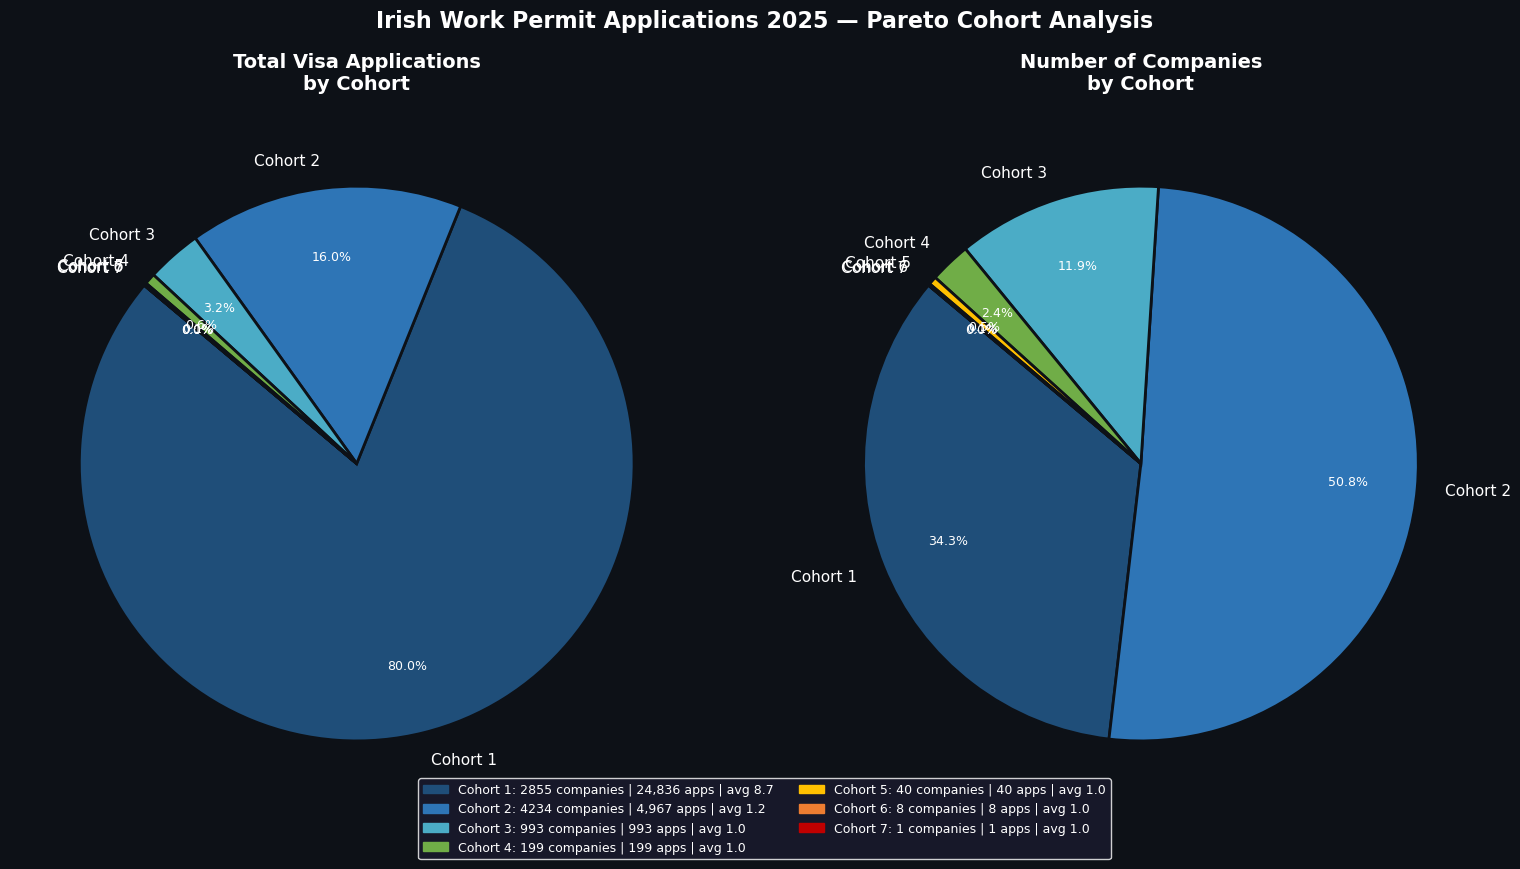

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Load & clean ---
df = pd.read_excel("permits-issued-to-companies-2025.xlsx", header=0, index_col=0)
df = df[df.index != 'Grand Total'].copy()
df = df[['Grand Total']].rename(columns={'Grand Total': 'Applications'})
df = df.dropna(subset=['Applications'])
df['Applications'] = df['Applications'].astype(int)
df = df.sort_values('Applications', ascending=False).reset_index()
df.columns = ['Company', 'Applications']

# --- Pareto segmentation: each cohort = top 80% of previous cohort ---
df['Cohort'] = ''
current = df[['Company', 'Applications']].copy()
current_indices = list(df.index)

for cohort_num in range(1, 8):
    if len(current) == 0:
        break
    group_total = current['Applications'].sum()
    target = group_total * 0.80
    cum = current['Applications'].cumsum().values
    cutoff_pos = next(i for i, v in enumerate(cum) if v >= target)
    top_indices = current_indices[:cutoff_pos + 1]
    df.loc[top_indices, 'Cohort'] = f'Cohort {cohort_num}'
    current_indices = current_indices[cutoff_pos + 1:]
    current = df.loc[current_indices, ['Company', 'Applications']]

df.loc[df['Cohort'] == '', 'Cohort'] = 'Cohort 7'

# --- Summary per cohort ---
summary = df.groupby('Cohort', sort=True).agg(
    Num_Companies=('Company', 'count'),
    Total_Applications=('Applications', 'sum'),
    Avg_Applications=('Applications', 'mean')
).round(1).reset_index()

print(summary)

# --- Plot ---
colors = ['#1f4e79','#2e75b6','#4bacc6','#70ad47','#ffc000','#ed7d31','#c00000']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#0d1117')

for ax, col, title in zip(axes,
    ['Total_Applications', 'Num_Companies'],
    ['Total Visa Applications\nby Cohort', 'Number of Companies\nby Cohort']):
    wedges, texts, autotexts = ax.pie(
        summary[col], labels=summary['Cohort'], autopct='%1.1f%%',
        colors=colors, startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor='#0d1117', linewidth=2))
    for t in texts: t.set_color('white'); t.set_fontsize(11)
    for at in autotexts: at.set_color('white'); at.set_fontsize(9)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=20)

legend_labels = [
    f"{r['Cohort']}: {r['Num_Companies']} companies | {r['Total_Applications']:,} apps | avg {r['Avg_Applications']:.1f}"
    for _, r in summary.iterrows()]
patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(len(summary))]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9,
           facecolor='#1a1a2e', edgecolor='white', labelcolor='white', bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Irish Work Permit Applications 2025 — Pareto Cohort Analysis',
             color='white', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('pareto_cohorts.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

   Cohort  VISA  Companies  Average
0       1  6569         66     99.5
1       2  1603         35     45.8
2       3  2026         61     33.2
3       4  2523        114     22.1
4       5  3180        244     13.0
5       6  3970        601      6.6
6       7  4965       1734      2.9
7       8  6208       5475      1.1


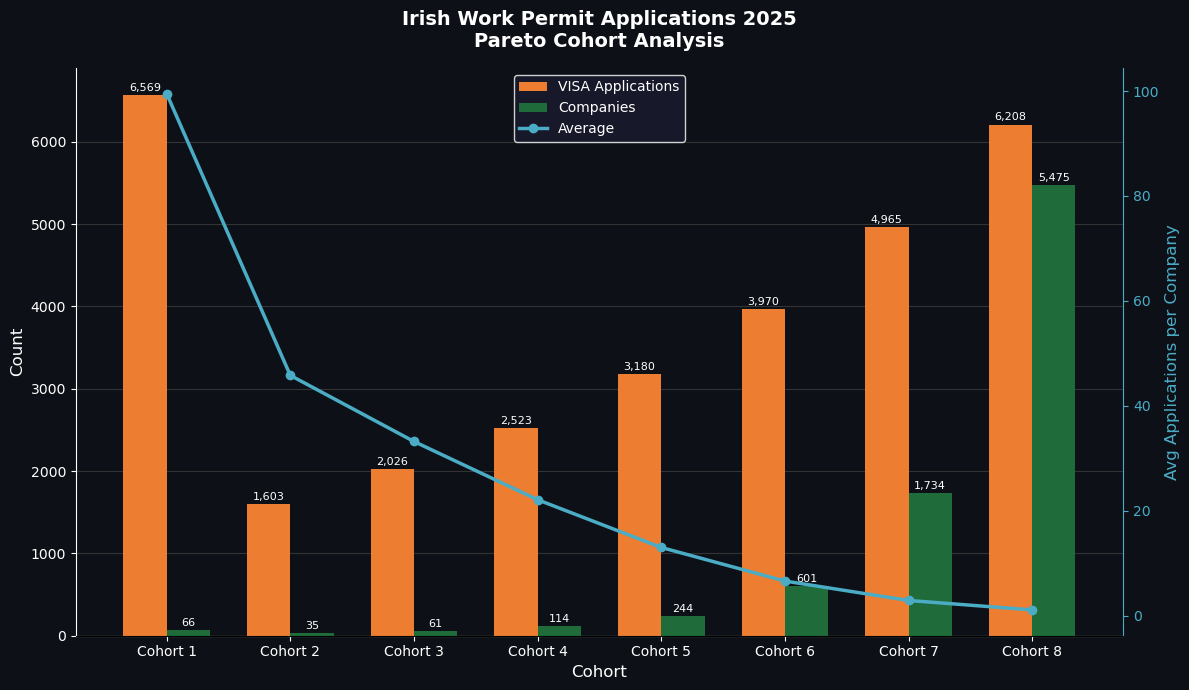

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load & clean ---
df = pd.read_excel("permits-issued-to-companies-2025.xlsx", header=0, index_col=0)
df = df[df.index != 'Grand Total'].copy()
df = df[['Grand Total']].rename(columns={'Grand Total': 'Applications'})
df = df.dropna(subset=['Applications'])
df['Applications'] = df['Applications'].astype(int)
df = df.sort_values('Applications', ascending=False).reset_index()
df.columns = ['Company', 'Applications']

# --- Segmentation: peel off bottom 20% repeatedly ---
# Each iteration: top 80% moves to next round, bottom 20% becomes a cohort
# Cohorts are assigned in reverse so Cohort 1 = the final top group

remaining = df.copy()
cohort_buckets = []  # will store from last cohort to first

for i in range(7):
    if len(remaining) == 0:
        break
    total = remaining['Applications'].sum()
    target = total * 0.80  # top 80%
    cum = remaining['Applications'].cumsum().values
    cutoff = next(i for i, v in enumerate(cum) if v >= target)
    
    top_80 = remaining.iloc[:cutoff+1].copy()   # moves to next round
    bottom_20 = remaining.iloc[cutoff+1:].copy()  # becomes a cohort
    
    cohort_buckets.append(bottom_20)
    remaining = top_80

# Whatever is left at the end = Cohort 1 (the very top)
cohort_buckets.append(remaining)

# Reverse so Cohort 1 is the top group
cohort_buckets.reverse()

# Assign cohort labels
all_cohorts = []
for i, bucket in enumerate(cohort_buckets):
    bucket = bucket.copy()
    bucket['Cohort'] = i + 1
    all_cohorts.append(bucket)

df_final = pd.concat(all_cohorts, ignore_index=True)

# --- Summary table ---
summary = df_final.groupby('Cohort').agg(
    VISA=('Applications', 'sum'),
    Companies=('Company', 'count'),
    Average=('Applications', 'mean')
).round(1).reset_index()

print(summary.to_string())

# --- Combo chart: bars for VISA & Companies, line for Average ---
fig, ax1 = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#0d1117')

x = np.arange(len(summary))
width = 0.35

bars1 = ax1.bar(x - width/2, summary['VISA'], width, label='VISA Applications',
                color='#ed7d31', zorder=3)
bars2 = ax1.bar(x + width/2, summary['Companies'], width, label='Companies',
                color='#1f6b3a', zorder=3)

ax1.set_xlabel('Cohort', color='white', fontsize=12)
ax1.set_ylabel('Count', color='white', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Cohort {c}' for c in summary['Cohort']], color='white')
ax1.tick_params(colors='white')
ax1.yaxis.label.set_color('white')
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', color='#333', zorder=0)

# Line for average on secondary axis
ax2 = ax1.twinx()
ax2.set_facecolor('#0d1117')
ax2.plot(x, summary['Average'], color='#4bacc6', linewidth=2.5,
         marker='o', markersize=6, label='Average', zorder=4)
ax2.set_ylabel('Avg Applications per Company', color='#4bacc6', fontsize=12)
ax2.tick_params(colors='#4bacc6')
ax2.spines['right'].set_color('#4bacc6')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', color='white', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', color='white', fontsize=8)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, facecolor='#1a1a2e',
           edgecolor='white', labelcolor='white', fontsize=10)

plt.title('Irish Work Permit Applications 2025\nPareto Cohort Analysis',
          color='white', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('cohort_combo_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()